# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import math
import scipy
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d    
import matplotlib.colors as mcolor
from scipy.integrate import quad

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
G = 6.67E-11
def Phi(M:float,xm:float,ym:float,X:float,Y:float) ->float:
    """
    This is a function that will compute the Gravitational Potential at a point (X,Y) of a Mass at point (xm,ym)
    Args:
        M (Float): The mass of the object
        Xm (Float): The X cordinate of the Object
        Ym (Float): The Y Cordinate of the Object
        X (Float): The X Cordinate of where you want to find the Potential 
        Y (Float): The Y Cordinate of where you want to find the Potential
    Returns: 
            Gravitational Potential at point (x,y) (Float)
    """   
    if M < 0:
        raise ValueError(f"The Mass cannot be negative")
    rx = X - xm
    ry = Y - ym
    r = np.sqrt(rx**2 + ry **2)
    if np.any(r==0):
        return np.nan
    Grav_Pot = -(G*M)/r
    assert Grav_Pot.any() != np.inf, "Singularity reached, the potenial cannot be infinite"
    return Grav_Pot
help(Phi)

Help on function Phi in module __main__:

Phi(M: float, xm: float, ym: float, X: float, Y: float) -> float
    This is a function that will compute the Gravitational Potential at a point (X,Y) of a Mass at point (xm,ym)
    Args:
        M (Float): The mass of the object
        Xm (Float): The X cordinate of the Object
        Ym (Float): The Y Cordinate of the Object
        X (Float): The X Cordinate of where you want to find the Potential
        Y (Float): The Y Cordinate of where you want to find the Potential
    Returns:
            Gravitational Potential at point (x,y) (Float)



2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

Text(0, 0.5, '$\\Phi$(r) (m/s)^2')

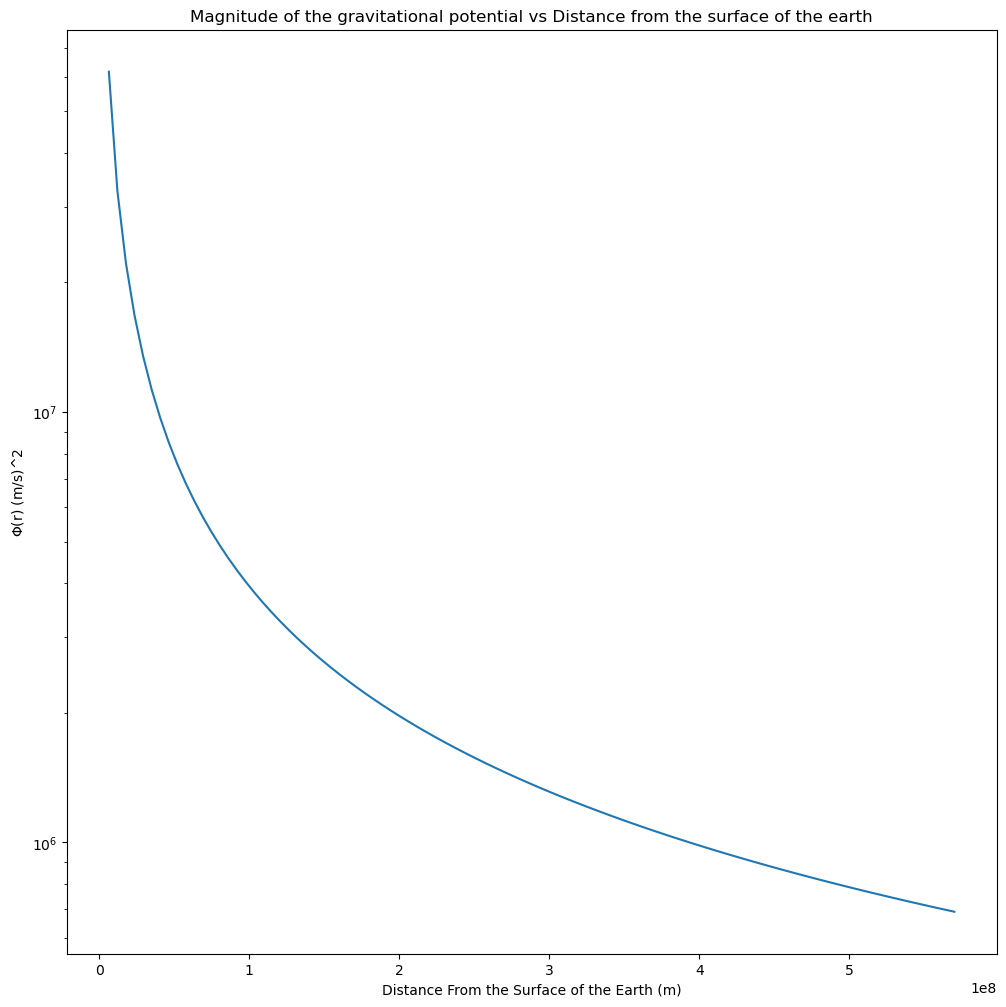

In [4]:
xm = 0 # This sets the center of mass in the X - Direction
ym = 0 # This sets the center of mass in the Y - Direction
L = 3.8E8 # Distance from the earth to the moon
R = 6378E3 # Radius of the Earth
x = np.linspace(R,1.5*L,100)
y = 0
M_E = 5.9E24
# Lets set the center of the earth at x = 0, y=0
Grav_Pot_Abs =np.abs(Phi(M_E,0,0,x,0))
fig, ax = plt.subplots(figsize=(12,12))
ax.semilogy(x,Grav_Pot_Abs)
ax.set_title("Magnitude of the gravitational potential vs Distance from the surface of the earth")
ax.set_xlabel("Distance From the Surface of the Earth (m)")
ax.set_ylabel(r'$\Phi$'"(r) (m/s)^2")

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

Text(0, 0.5, 'Y(m)')

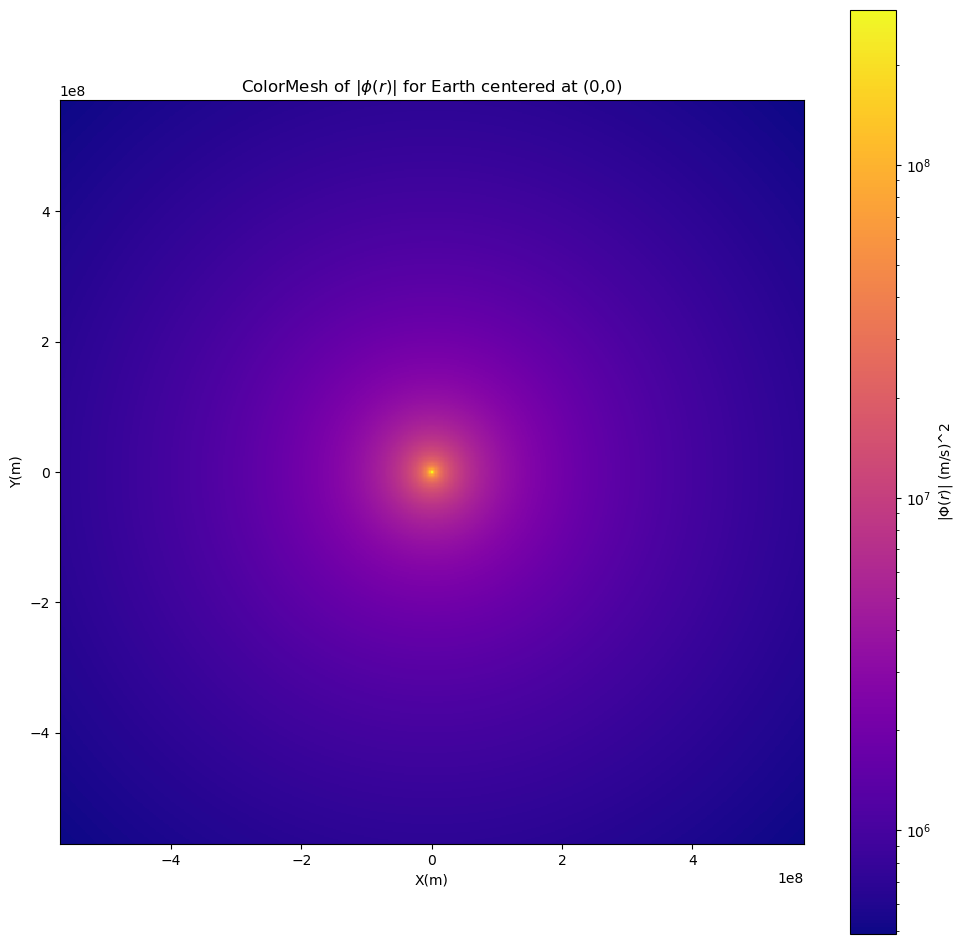

In [5]:
L = 3.8E8 # Distance from the earth to the moon
x = np.linspace(-1.5*L,1.5*L,600)
y = np.linspace(-1.5*L,1.5*L,600)
(x,y) = np.meshgrid(x,y)
Grav_Pot_Abs =np.abs(Phi(M_E,0,0,x,y))
fig,ax = plt.subplots(figsize=(12,12))
plot = ax.pcolormesh(x,y,Grav_Pot_Abs,shading="auto",cmap = "plasma", norm="log")
fig.colorbar(plot,ax=ax,label = r'|$\Phi(r)$| (m/s)^2')
ax.set_aspect('equal')
ax.set_title("ColorMesh of" r' $|\phi(r)|$' " for Earth centered at (0,0)")
ax.set_xlabel("X(m)")
ax.set_ylabel("Y(m)")

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

292438071.6420058
492294.1312924494


Text(0, 0.5, 'Y(m)')

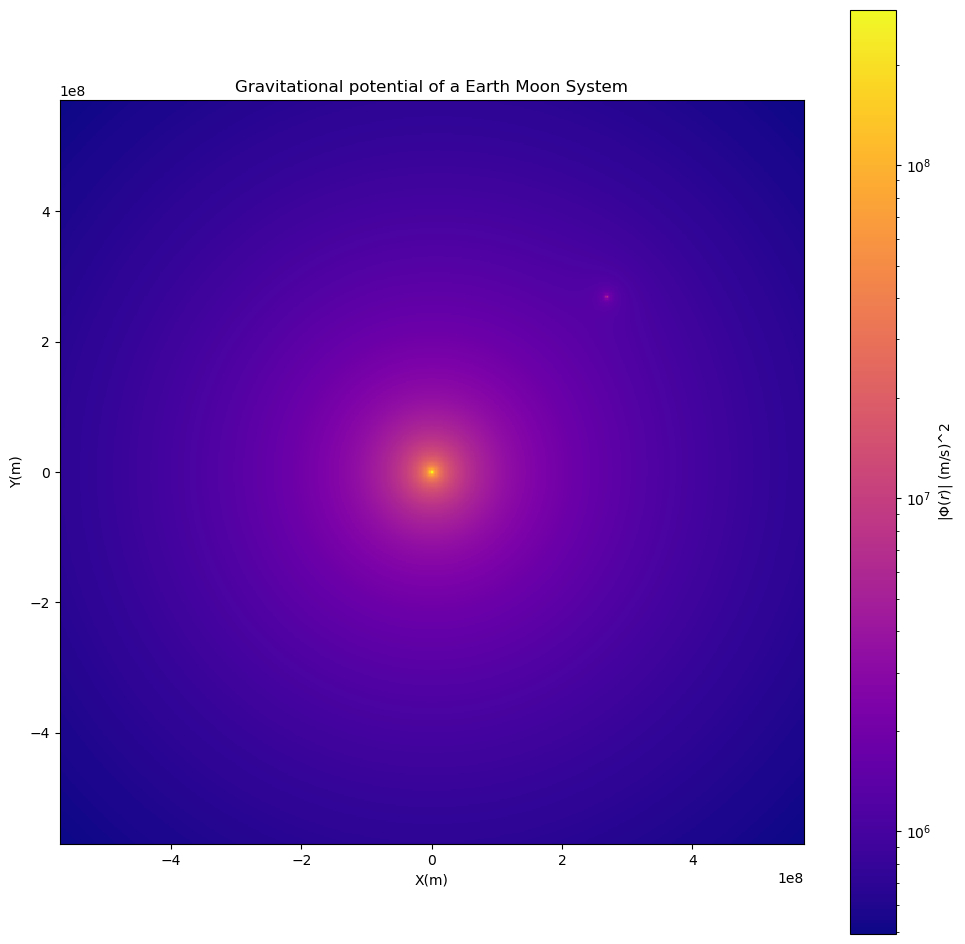

In [6]:
M_M = 7.3E22
Xm = L/np.sqrt(2) 
Ym = L/np.sqrt(2) 
Earth_Pot = Phi(M_E,0,0,x,y)
Moon_Pot = Phi(M_M,Xm,Ym,x,y) 
Total_Potential = np.abs(Earth_Pot + Moon_Pot)
Total_potential_Max = Total_Potential.max()
Total_potential_Min = Total_Potential.min()
print(Total_potential_Max)
print(Total_potential_Min)
fig,ax = plt.subplots(figsize=(12,12))
plot = ax.pcolormesh(x,y,Total_Potential,cmap = "plasma", norm = "log")
fig.colorbar(plot,ax=ax,label= r'|$\Phi(r)$| (m/s)^2')
ax.set_aspect('equal')
ax.set_title("Gravitational potential of a Earth Moon System")
ax.set_xlabel("X(m)")
ax.set_ylabel("Y(m)")

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

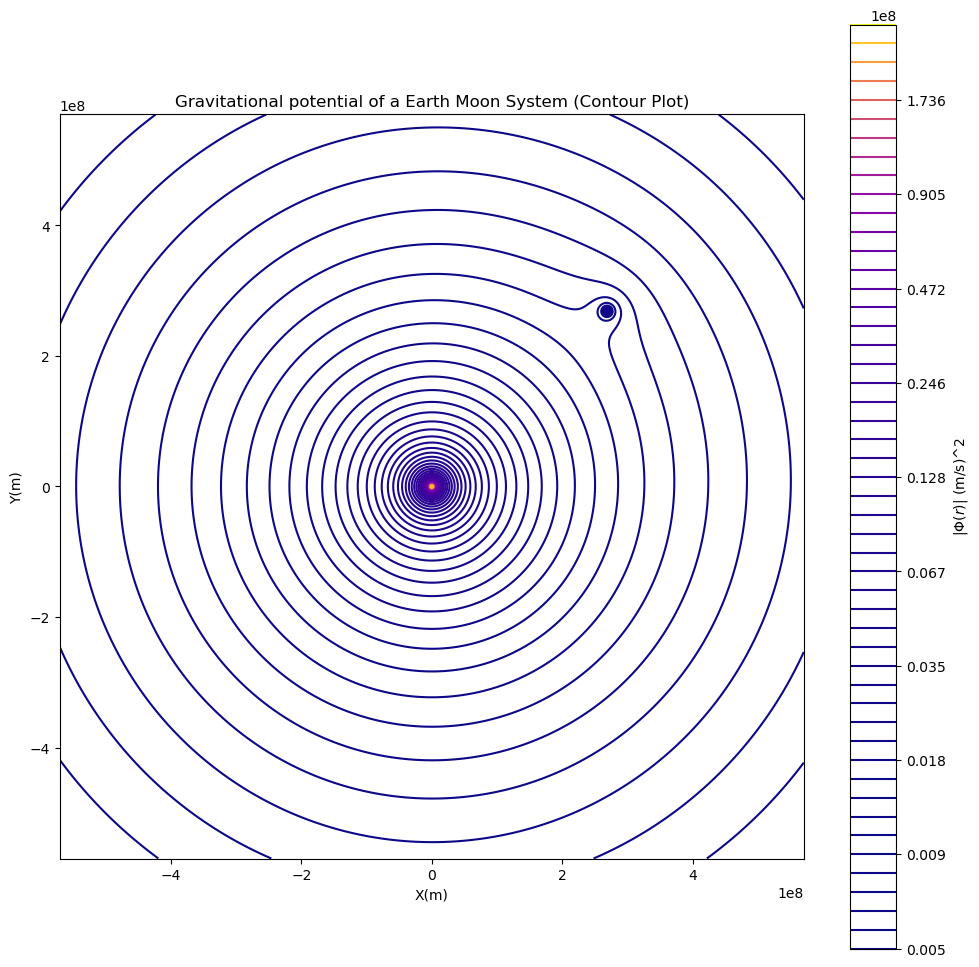

In [7]:
Phi_max = Total_Potential.max()
Phi_min = Total_Potential.min()
levels = np.logspace(np.log10(Phi_min),np.log10(Phi_max),50)
fig,ax =plt.subplots(figsize=(12,12))
plot = ax.contour(x,y,Total_Potential,levels=levels,cmap = "plasma")
ax.set_aspect('equal')
ax.set_title("Gravitational potential of a Earth Moon System (Contour Plot)")
ax.set_xlabel("X(m)")
ax.set_ylabel("Y(m)")
fig.colorbar(plot,ax=ax,label=r'|$\Phi(r)$| (m/s)^2')

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
G = 6.67E-11
def GravF(M:float,m:float,x1:float,y1:float,x2:float,y2:float) ->float:
    """
    This Function will calculate the Gravitational Force between two Objects of Mass M1 at (X1,Y1) and Mass M2 at (X2,Y2)
    Args:
        M(Float): The mass of Object 1 
        m(Float): The mass of Object 2
        x1(Float): The X postion of Object 1
        y1(Float): The Y postion of Object 1
        x2(Float): The X postion of Object 2
        y2(Float): The Y postion of Object 2
    return: The Force components between the two Objects of Mass M1, and Mass M2 
    """
    
    if M <0 or m < 0:
        raise ValueError(f"The Mass cannot be negative")
    rx = x2 -x1
    ry = y2 -y1
    r2_mag = rx**2 + ry**2
    r_mag = np.sqrt(r2_mag)
    if np.any(r_mag == 0):
        return np.nan
    F_21 = -(G*M*m)/r2_mag
    rx_hat = rx/r_mag
    ry_hat = ry/r_mag
    Fx = F_21*rx_hat
    Fy = F_21*ry_hat
    return Fx,Fy
help(GravF)


Help on function GravF in module __main__:

GravF(M: float, m: float, x1: float, y1: float, x2: float, y2: float) -> float
    This Function will calculate the Gravitational Force between two Objects of Mass M1 at (X1,Y1) and Mass M2 at (X2,Y2)
    Args:
        M(Float): The mass of Object 1
        m(Float): The mass of Object 2
        x1(Float): The X postion of Object 1
        y1(Float): The Y postion of Object 1
        x2(Float): The X postion of Object 2
        y2(Float): The Y postion of Object 2
    return: The Force components between the two Objects of Mass M1, and Mass M2



2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

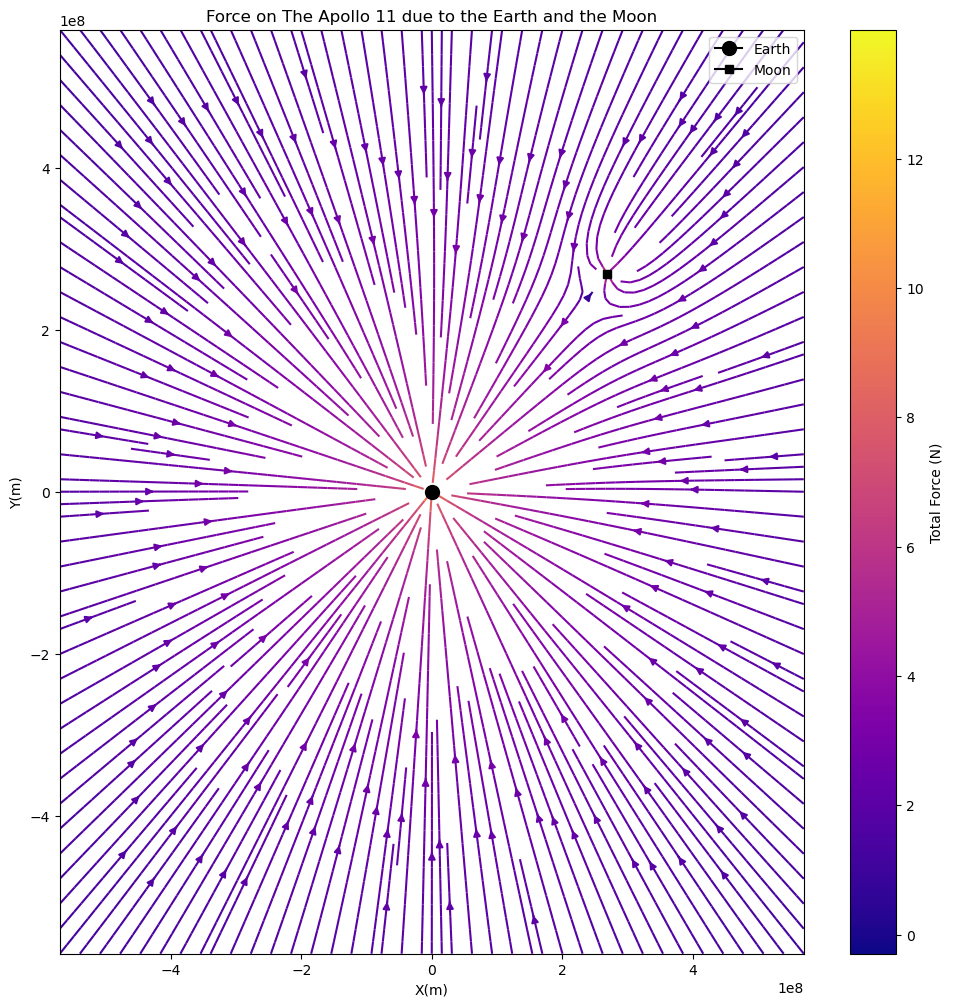

In [9]:
M_A  = 5500.0 #kg
M_E = 5.9E24 #kg
M_M = 7.3E22 #kg
L = 3.8E8 # Distance from the earth to the moon
Xm = L/(np.sqrt(2))
Ym = L/(np.sqrt(2))
x = np.linspace(-1.5*L,1.5*L,600)
y = np.linspace(-1.5*L,1.5*L,600)
(x,y) = np.meshgrid(x,y)
F_Ex, F_Ey = GravF(M_E,M_A,0,0,x,y)
F_Mx, F_My = GravF(M_M,M_A,Xm,Ym,x,y)
F_Tx = F_Ex + F_Mx
F_Ty = F_Ey + F_My
F_T = np.sqrt(F_Tx**2 + F_Ty**2)
fig, ax = plt.subplots(figsize = (12,12))
plot = ax.streamplot(x,y,F_Tx,F_Ty,density=2.5, color = np.log(F_T),cmap = "plasma")
ax.plot(0,0, marker = 'o' , c = 'black', markersize = 10,label = "Earth")
ax.plot(Xm,Ym, marker = 's' , c = 'black', markersize = 6,label = "Moon")
ax.set_title("Force on The Apollo 11 due to the Earth and the Moon")
ax.set_xlabel("X(m)")
ax.set_ylabel("Y(m)")
ax.legend()
fig.colorbar(plot.lines,ax=ax,label = "Total Force (N)")

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

## Finding the R, at which $|\vec{F}_{moon}|$ = $|\vec{F}_{Earth}|$
$\vec{F}_{Earth} = G \frac{M_E M_A}{|\vec{r}|^2}$
$\vec{F}_{Moon} = G \frac{M_M M_A}{|\vec{r_m-r}|^2}$
With $r_m = \sqrt{X_M^2 + Y_M^2}$
\
$G \frac{M_E M_A}{|\vec{r}|^2} = G \frac{M_M M_A}{|\vec{r_m-r}|^2}$
\
$ \frac{\sqrt{M_E}}{|\vec{r}|} = \frac{\sqrt{M_M}}{|\vec{r_m-r}|}$
\
$\sqrt{\frac{M_M}{M_E}}$ = $\frac{r_m-r}{r}$
\
$\sqrt{\frac{M_M}{M_E}}$ = $-1+\frac{r_m}{r}$
\
$\frac{r_m}{r}$ =$1 + \sqrt{\frac{M_M}{M_E}}$ 
\
$r = \frac{r_m}{1 + \sqrt{\frac{M_M}{M_E}}}$

And your updated plot, including the balance point, goes in the cell below.

Balance Point: 341962346.9118151 m
Ratio of R to L 0.8999009129258294
Force at the balance point from the Earth: (np.float64(-13.08786959716515), np.float64(-13.08786959716515)) (N)
Force at the balance point from the Moon: (np.float64(13.087869597165161), np.float64(13.087869597165161)) (N)


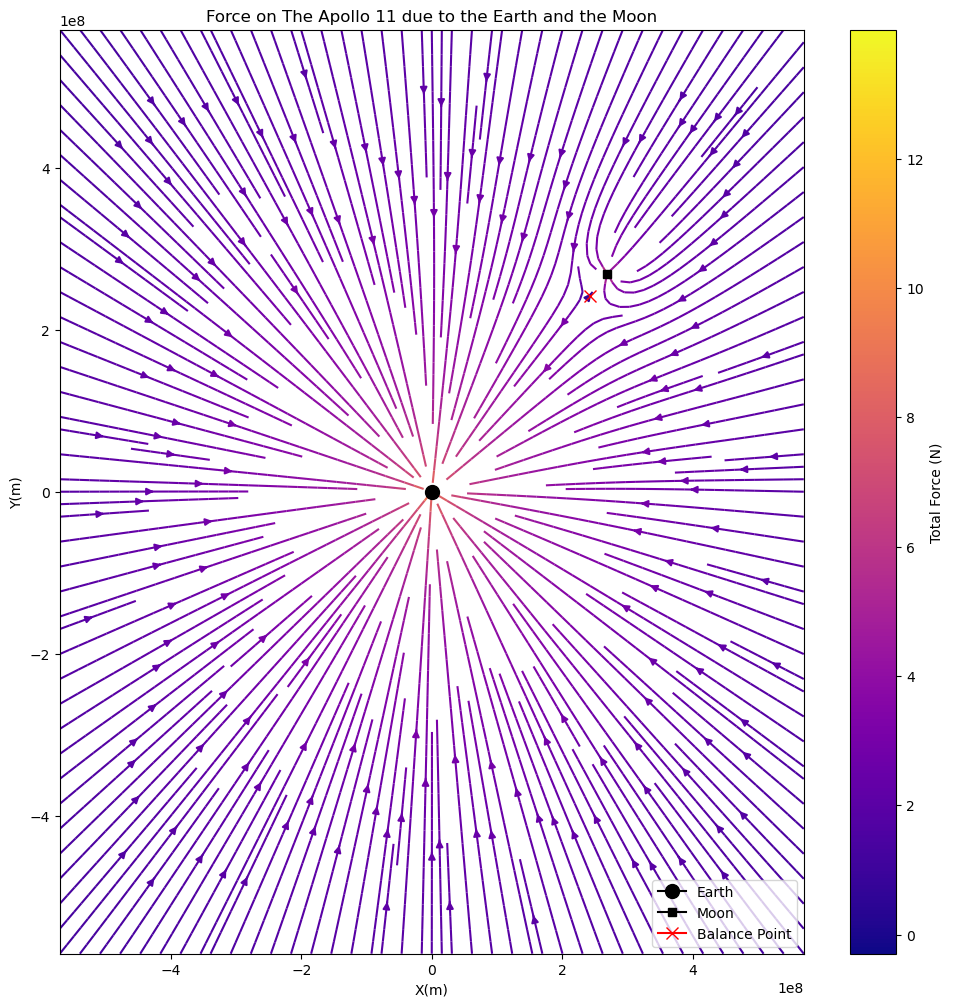

In [10]:
R_m = np.sqrt(Xm**2 + Ym**2)
R = R_m/(1+np.sqrt(M_M/M_E))
Theta = np.atan2(Ym,Xm)
Rx= R*np.cos(Theta)
Ry= R*np.sin(Theta)
print("Balance Point:",R,"m")
print("Ratio of R to L",R/R_m)
fig, ax = plt.subplots(figsize = (12,12))
plot = ax.streamplot(x,y,F_Tx,F_Ty,density=2.5, color = np.log(F_T),cmap = "plasma")
ax.plot(0,0, marker = 'o' , c = 'black', markersize = 10,label = "Earth")
ax.plot(Xm,Ym, marker = 's' , c = 'black', markersize = 6,label = "Moon")
ax.plot(Rx,Ry, marker = 'x' , c = 'red', markersize =8,label = "Balance Point")
ax.set_title("Force on The Apollo 11 due to the Earth and the Moon")
ax.set_xlabel("X(m)")
ax.set_ylabel("Y(m)")
ax.legend()
fig.colorbar(plot.lines,ax=ax,label = "Total Force (N)")
print("Force at the balance point from the Earth:",GravF(M_E,M_A,0,0,Rx,Ry),"(N)")
print("Force at the balance point from the Moon:",GravF(M_M,M_A,Xm,Ym,Rx,Ry),"(N)")

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

### Is the Balance Point Closer to the Moon or the Earth?
The Balance Point is much closer to the moon than it is to the earth. The Ratio of the R to $R_m$ (the Distance from the Earth to the Moon) is about 0.9, 
\
demostrates that R is about 90% of the distance as $R_M$, which and thus being much closer to the moon. This make sense as the moon is drastically 
\
less massive than the earth. Since the Force Scales linearly with mass, and the force scales with $\frac{1}{r^2}$, for the forces to
\
balance it must be much closer to the moon as that would increase the force the rocket feels from the moon while decreasing the force,
\
the rocket feels from the Earth. We can double check this by plugging in Rx and Ry into our function for both an Object with Mass $M_E$ and $M_M$
\
and we find that the Fx and Fy values for both are about 13 Newtons, and thus illustrates a balance.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
m0 = 2.8E6 #kg
mf = 7.5E5 #kg
m_dot = 1.3E4 #kg/s
T = (m0-mf)/m_dot
print("Total Burn Time:",T,"(s)")

Total Burn Time: 157.69230769230768 (s)


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
m0 = 2.8E6 #kg
mf = 7.5E5 #kg
m_dot = 1.3E4 #kg/s
g = 9.81 #(m/s)^2
T = (m0-mf)/m_dot #s
Ve = 2.4E3 #m/s
def deltaV(t:float,m_0:float,m_f:float,dm:float,ve:float,g:float) -> float:
        """
        This Function Calculates the Change in Velocity of the Saturn V rocket
            Args:
                t(float): This is the Time spent flying of the Rocket
                m_0(float): Wet Mass of the Rocket
                m_f(float): Dry Mass of the Rocket
                dm(float): Burn rate of the rocket
                ve(float): Exhaust speed of the rocket
                g(float): Acceleration due to gravity
            returns:
                    Nan if the mt is zero, this is to avoid any infinites 
                    0 if t = T as this is when the rocket is out of fuel 
                    The Delta V
        """
        mt = m_0 - dm*t
        if mt == 0:
            return np.nan
        if t >= T:
            return 0
        V = ve*np.log(m_0/mt) - g*t
        if V < 0:
            return 0
        return V

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
H = scipy.integrate.quad(deltaV,0,T,args=(m0,mf,m_dot,Ve,g))
print("Total Distance Travled",H[0],"(m)")
print("Total Distance Travled Uncertainty",H[1],"(m)")

Total Distance Travled 74093.98013366401 (m)
Total Distance Travled Uncertainty 5.848811185394157e-08 (m)


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

## Why are the predicted values diffrent than the measured one?

I Found my Total burn Time T to be 157.69 Seconds, and I found my total Height H to be about 74093.98 M or 74.09 Km. These differ from the measured values of T = 160 Seconds and h = 70km. The predicted T and the measured T aren't too far off, only off by about 2.3 seconds. This can be explained by a couple things, the small diffrence could possibly be caused by the assumption that the fuel burn rate is constant. While it could be constant through the some of the flight, it could also vary through other parts, resulting in less fuel being consumed resulting in a longer burn time. For the total distance, a couple of things could explain why the predicted H was about 4km more than the measured value. One thing is that the equation used neglect drag, drag would slow the rocket down via decleration, which would result in a smaller H than predicted. Another thing could be Ve is not constant and varies a little, which could result in a smaller $V_E$ at times and thus cause a smaller H.